# Qualitative results

This notebook compares qualitative outputs across the full experiment set:

- baseline encoder-decoder + global min-max
- U-Net + global min-max
- baseline encoder-decoder + percentile min-max
- U-Net + percentile min-max
- ResUNet + global min-max

The goal is not just to identify which image looks sharpest, but to inspect:

- blur vs structural detail
- background behaviour
- artifact severity
- the effect of normalization

In [1]:
from pathlib import Path
import json
import sys
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_from_disk

ROOT = Path("..").resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from mri_translation.engine.evaluate import load_checkpoint
from mri_translation.engine.train import resolve_device
from mri_translation.models.factory import build_model

plt.rcParams["image.cmap"] = "gray"
DEVICE = resolve_device("auto")

/home/dreadgator/mri-modality-translation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RUN_SPECS = {
    "Baseline + global": {
        "config": ROOT / "configs" / "baseline_encoder_decoder_global_minmax.yaml",
        "checkpoint": ROOT / "outputs" / "runs" / "baseline_encoder_decoder_global_minmax" / "best.pt",
        "metrics": ROOT / "outputs" / "runs" / "baseline_encoder_decoder_global_minmax" / "metrics_test.json",
        "model_name": "baseline_encoder_decoder",
        "normalization": "global min-max",
    },
    "U-Net + global": {
        "config": ROOT / "configs" / "unet_global_minmax.yaml",
        "checkpoint": ROOT / "outputs" / "runs" / "unet_global_minmax" / "best.pt",
        "metrics": ROOT / "outputs" / "runs" / "unet_global_minmax" / "metrics_test.json",
        "model_name": "unet",
        "normalization": "global min-max",
    },
    "Baseline + percentile": {
        "config": ROOT / "configs" / "baseline_encoder_decoder_percentile_minmax.yaml",
        "checkpoint": ROOT / "outputs" / "runs" / "baseline_encoder_decoder_percentile_minmax" / "best.pt",
        "metrics": ROOT / "outputs" / "runs" / "baseline_encoder_decoder_percentile_minmax" / "metrics_test.json",
        "model_name": "baseline_encoder_decoder",
        "normalization": "percentile min-max",
    },
    "U-Net + percentile": {
        "config": ROOT / "configs" / "unet_percentile_minmax.yaml",
        "checkpoint": ROOT / "outputs" / "runs" / "unet_percentile_minmax" / "best.pt",
        "metrics": ROOT / "outputs" / "runs" / "unet_percentile_minmax" / "metrics_test.json",
        "model_name": "unet",
        "normalization": "percentile min-max",
    },
    "ResUNet + global": {
        "config": ROOT / "configs" / "resunet_global_minmax.yaml",
        "checkpoint": ROOT / "outputs" / "runs" / "resunet_global_minmax" / "best.pt",
        "metrics": ROOT / "outputs" / "runs" / "resunet_global_minmax" / "metrics_test.json",
        "model_name": "resunet",
        "normalization": "global min-max",
    },
}

In [3]:
def load_yaml(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)

def robust_range(*arrays, lower=1.0, upper=99.0):
    stacked = np.concatenate([np.asarray(arr).reshape(-1) for arr in arrays])
    vmin = float(np.percentile(stacked, lower))
    vmax = float(np.percentile(stacked, upper))
    if vmax <= vmin:
        vmax = vmin + 1e-6
    return vmin, vmax

In [4]:
reference_cfg = load_yaml(RUN_SPECS["ResUNet + global"]["config"])
dataset_dir = ROOT / reference_cfg["data"]["local_dataset_dir"]
split_dir = ROOT / reference_cfg["data"]["split"]["split_dir"]

full_ds = load_from_disk(str(dataset_dir))

with open(split_dir / "split_manifest.json", "r", encoding="utf-8") as f:
    split_manifest = json.load(f)

sample_id_to_index = {str(full_ds[i]["sample_id"]): i for i in range(len(full_ds))}
test_ids = split_manifest["splits"]["test"]
test_indices = [sample_id_to_index[sid] for sid in test_ids]

print("full dataset:", len(full_ds))
print("test samples:", len(test_indices))

full dataset: 155610
test samples: 24570


In [5]:
selected_dataset_indices = []
used_patients = set()

for target_view in ["axial", "coronal", "sagittal"]:
    for idx in test_indices:
        sample = full_ds[idx]
        if sample["view"] == target_view and sample["patient_id"] not in used_patients:
            selected_dataset_indices.append(idx)
            used_patients.add(sample["patient_id"])
            break

for idx in test_indices[len(test_indices)//2:]:
    sample = full_ds[idx]
    if sample["patient_id"] not in used_patients:
        selected_dataset_indices.append(idx)
        break

selected_dataset_indices = list(dict.fromkeys(selected_dataset_indices))[:4]
selected_dataset_indices

[4410, 6495, 7320, 94185]

In [6]:
sample_rows = []
for idx in selected_dataset_indices:
    sample = full_ds[idx]
    sample_rows.append(
        {
            "dataset_index": idx,
            "sample_id": sample["sample_id"],
            "patient_id": sample["patient_id"],
            "view": sample["view"],
            "source_split": sample.get("source_split", ""),
        }
    )

selected_samples_df = pd.DataFrame(sample_rows)
selected_samples_df

,dataset_index,sample_id,patient_id,view,source_split
0,4410,train_004410,310,axial,train
1,6495,train_006495,048,coronal,train
2,7320,train_007320,045,sagittal,train
3,94185,train_094185,296,axial,train


In [7]:
train_ids = split_manifest["splits"]["train"]
train_indices = [sample_id_to_index[sid] for sid in train_ids[::200]]

t1_pixels = []
t2_pixels = []

for idx in train_indices:
    sample = full_ds[idx]
    t1_pixels.append(np.asarray(sample["t1"], dtype=np.float32).reshape(-1))
    t2_pixels.append(np.asarray(sample["t2"], dtype=np.float32).reshape(-1))

t1_pixels = np.concatenate(t1_pixels)
t2_pixels = np.concatenate(t2_pixels)

def estimate_stats(pixel_array: np.ndarray):
    return {
        "min": float(pixel_array.min()),
        "max": float(pixel_array.max()),
        "p1": float(np.percentile(pixel_array, 1.0)),
        "p99_5": float(np.percentile(pixel_array, 99.5)),
    }

t1_stats = estimate_stats(t1_pixels)
t2_stats = estimate_stats(t2_pixels)

In [8]:
def normalize_arr(arr: np.ndarray, method: str, stats: dict) -> np.ndarray:
    if method == "global_minmax":
        low, high = stats["min"], stats["max"]
    elif method == "percentile_minmax":
        low, high = stats["p1"], stats["p99_5"]
    else:
        raise ValueError(f"Unknown normalization method: {method}")

    denom = max(high - low, 1e-8)
    return np.clip((arr - low) / denom, 0.0, 1.0)

In [9]:
summary_rows = []
for label, spec in RUN_SPECS.items():
    with open(spec["metrics"], "r", encoding="utf-8") as f:
        metrics = json.load(f)

    summary_rows.append(
        {
            "run": label,
            "normalization": spec["normalization"],
            "mse": metrics["mse"],
            "rmse": metrics["rmse"],
            "ssim": metrics["ssim"],
        }
    )

qual_summary_df = pd.DataFrame(summary_rows).sort_values("mse")
qual_summary_df

tables_dir = ROOT / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)
qual_summary_df.to_csv(tables_dir / "qualitative_summary_table.csv", index=False)
(tables_dir / "qualitative_summary_table.md").write_text(
    qual_summary_df.to_markdown(index=False), encoding="utf-8"
)
print("Saved qualitative summary table to", tables_dir)

Saved qualitative summary table to /home/dreadgator/mri-modality-translation/reports/tables


## Why this notebook does not rely on the saved training grids alone

Each run already saved a `prediction_grid.png` artifact during training, but those grids do not necessarily show the same test examples across models.

For a fair qualitative comparison, this notebook regenerates predictions from the saved best checkpoints on a shared fixed subset of held-out test samples.

## Qualitative comparison setup

The panels below compare all runs on the **same fixed held-out test samples**.

This matters because the saved `prediction_grid.png` files from training are useful run artifacts, but they do not necessarily show the same examples across models. For a fair qualitative comparison, the notebook generates predictions from the saved best checkpoints on a shared sample set.

In [10]:
def predict_for_run(run_spec, dataset_indices):
    cfg = load_yaml(run_spec["config"])
    norm_method = cfg["data"]["normalization"]["method"]

    inputs = []
    targets = []
    views = []

    for idx in dataset_indices:
        sample = full_ds[idx]
        t1 = np.asarray(sample["t1"], dtype=np.float32).squeeze()
        t2 = np.asarray(sample["t2"], dtype=np.float32).squeeze()

        t1 = normalize_arr(t1, norm_method, t1_stats)
        t2 = normalize_arr(t2, norm_method, t2_stats)

        inputs.append(torch.tensor(t1, dtype=torch.float32).unsqueeze(0))
        targets.append(torch.tensor(t2, dtype=torch.float32).unsqueeze(0))
        views.append(sample["view"])

    batch_input = torch.stack(inputs).to(DEVICE)
    batch_target = torch.stack(targets)

    model = build_model(run_spec["model_name"]).to(DEVICE)
    load_checkpoint(model, run_spec["checkpoint"], DEVICE)
    model.eval()

    with torch.no_grad():
        pred = model(batch_input)
        pred = torch.clamp(pred, 0.0, 1.0).cpu()

    return {
        "input": batch_input.cpu(),
        "target": batch_target,
        "pred": pred,
        "view": views,
    }

run_outputs = {}
for label, spec in RUN_SPECS.items():
    print("running:", label)
    run_outputs[label] = predict_for_run(spec, selected_dataset_indices)

print("done")

running: Baseline + global
running: U-Net + global
running: Baseline + percentile
running: U-Net + percentile
running: ResUNet + global
done


## Full qualitative ablation panel

This panel compares all five experiment variants on the same fixed held-out test samples.

It is the most useful figure for the normalization story, because it makes it clear that the percentile-minmax runs were not just slightly worse numerically — they also changed the visual behaviour of the models in unstable ways.

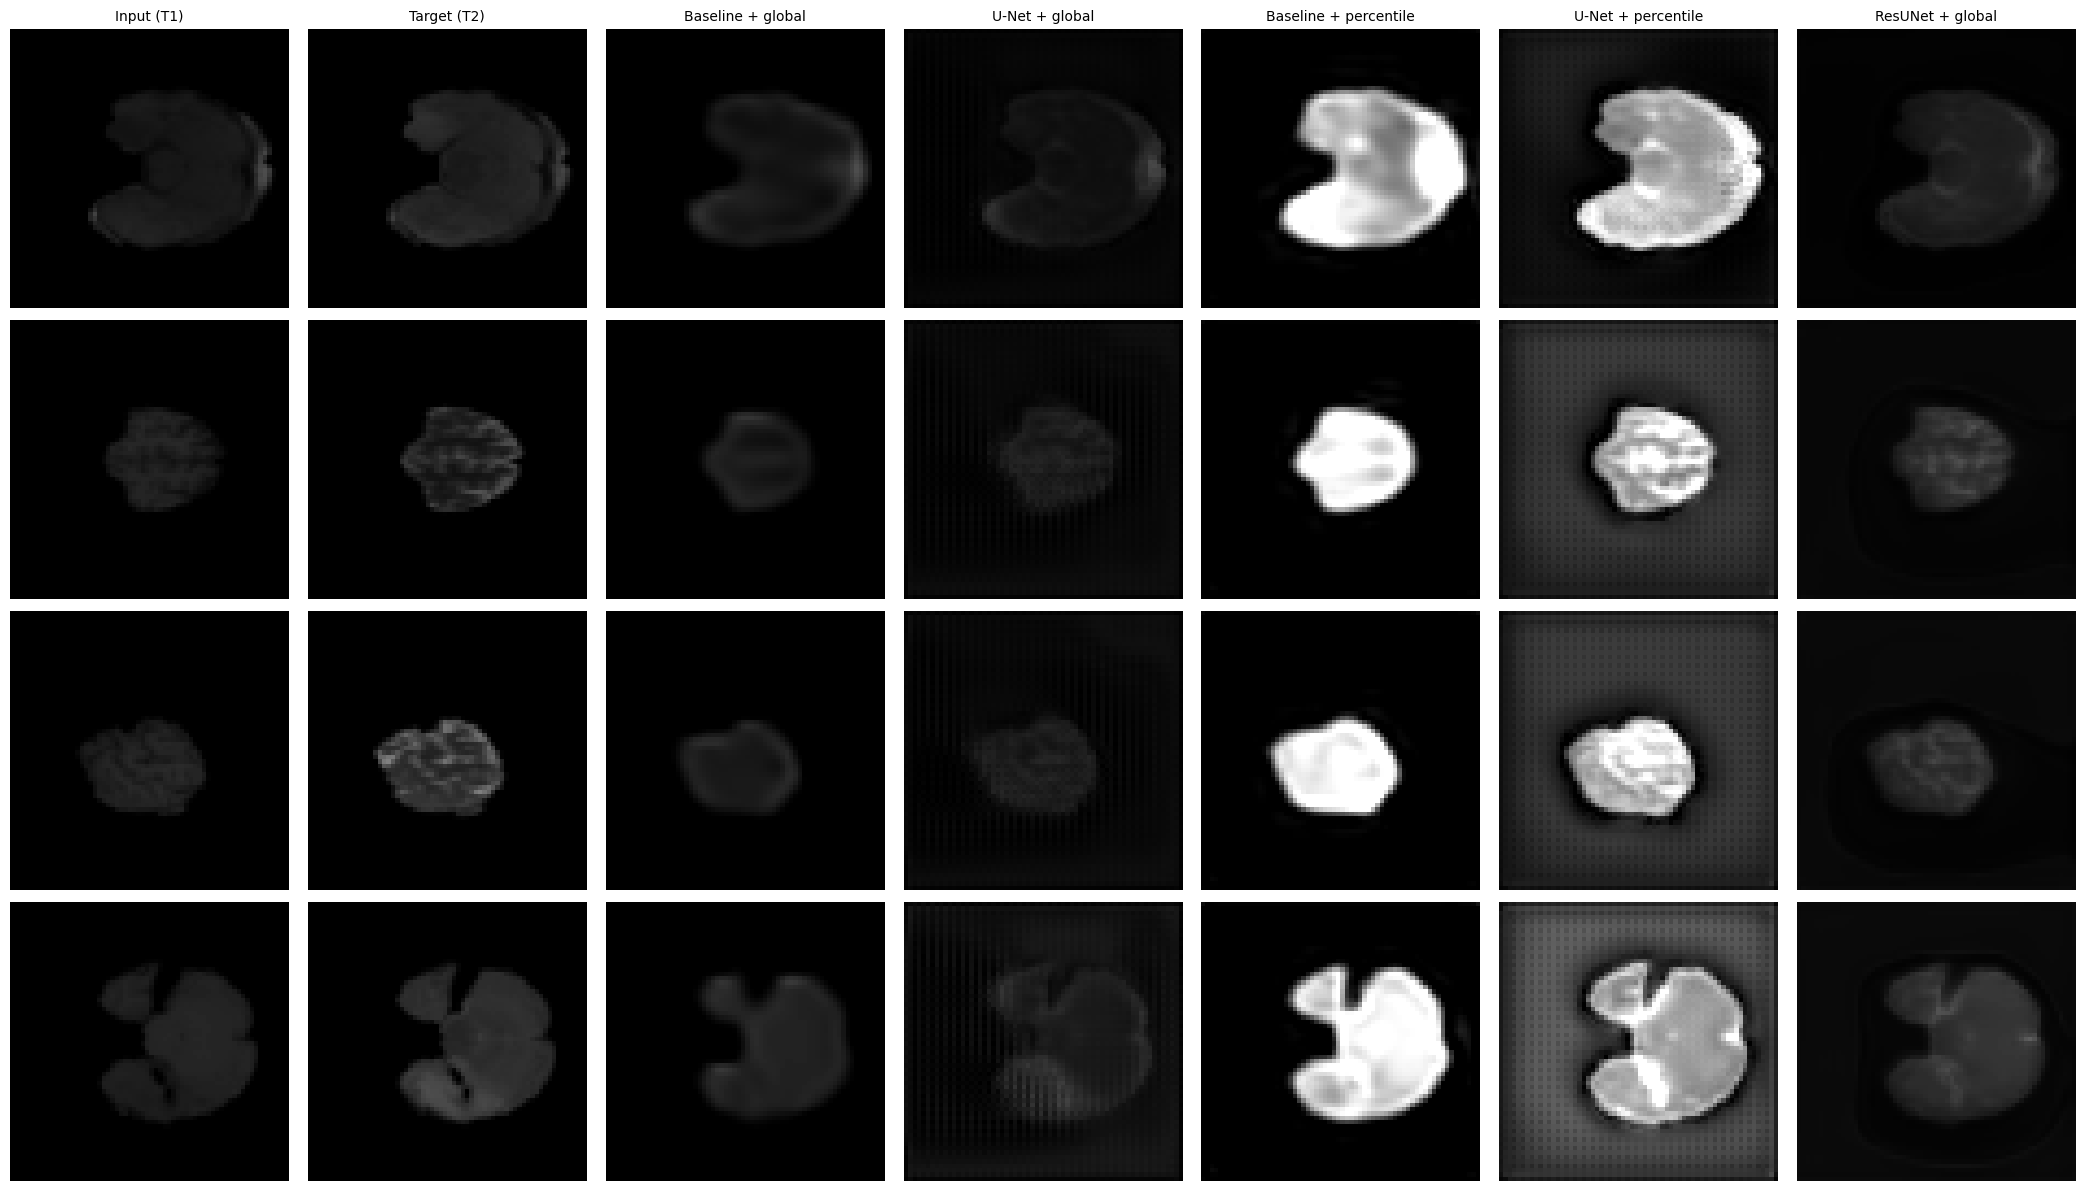

In [11]:
row_labels = [
    f"test sample {idx} ({run_outputs['ResUNet + global']['view'][i]})"
    for i, idx in enumerate(selected_dataset_indices)
]
col_labels = ["Input (T1)", "Target (T2)"] + list(run_outputs.keys())

fig, axes = plt.subplots(
    len(selected_dataset_indices),
    len(col_labels),
    figsize=(3 * len(col_labels), 3 * len(selected_dataset_indices)),
)

for row_idx, sample_idx in enumerate(selected_dataset_indices):
    ref_input = run_outputs["ResUNet + global"]["input"][row_idx, 0].numpy()
    ref_target = run_outputs["ResUNet + global"]["target"][row_idx, 0].numpy()
    pred_arrays = [run_outputs[label]["pred"][row_idx, 0].numpy() for label in run_outputs]
    vmin, vmax = robust_range(ref_input, ref_target, *pred_arrays, lower=1.0, upper=99.0)

    images = [ref_input, ref_target] + pred_arrays
    for col_idx, img in enumerate(images):
        axes[row_idx, col_idx].imshow(img, vmin=vmin, vmax=vmax)
        axes[row_idx, col_idx].axis("off")
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(col_labels[col_idx], fontsize=10)

    axes[row_idx, 0].set_ylabel(row_labels[row_idx], fontsize=10)

plt.tight_layout()
plt.show()

### Interpretation of the full ablation panel

- The **global-minmax encoder-decoder** is stable but visibly blurry.
- The **global-minmax U-Net** restores more structure, but also introduces visible background artifacts.
- The **percentile-minmax runs** do not provide a robust improvement despite occasional visually appealing cases.
- The **global-minmax ResUNet** gives the strongest overall balance between structure, stability, and reduced artifact severity.

In [12]:
save_path = ROOT / "reports" / "figures" / "qualitative_ablation_panel.png"
save_path.parent.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(len(selected_dataset_indices), len(col_labels), figsize=(3 * len(col_labels), 3 * len(selected_dataset_indices)))

for row_idx, sample_idx in enumerate(selected_dataset_indices):
    ref_input = run_outputs["ResUNet + global"]["input"][row_idx, 0].numpy()
    ref_target = run_outputs["ResUNet + global"]["target"][row_idx, 0].numpy()
    pred_arrays = [run_outputs[label]["pred"][row_idx, 0].numpy() for label in run_outputs]
    vmin, vmax = robust_range(ref_input, ref_target, *pred_arrays, lower=1.0, upper=99.0)

    images = [ref_input, ref_target] + pred_arrays
    for col_idx, img in enumerate(images):
        axes[row_idx, col_idx].imshow(img, vmin=vmin, vmax=vmax)
        axes[row_idx, col_idx].axis("off")
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(col_labels[col_idx], fontsize=10)

    axes[row_idx, 0].set_ylabel(row_labels[row_idx], fontsize=10)

plt.tight_layout()
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.close()

print("Saved:", save_path)

Saved: /home/dreadgator/mri-modality-translation/reports/figures/qualitative_ablation_panel.png


In [13]:
tables_dir = ROOT / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

selected_samples_df.to_csv(tables_dir / "qualitative_selected_samples.csv", index=False)
(tables_dir / "qualitative_selected_samples.md").write_text(
    selected_samples_df.to_markdown(index=False), encoding="utf-8"
)
print("Saved selected sample metadata to", tables_dir)

Saved selected sample metadata to /home/dreadgator/mri-modality-translation/reports/tables


## Focused final-model comparison

This smaller panel isolates the three most important final global-minmax runs:

- baseline encoder-decoder
- U-Net
- ResUNet

This is the comparison most worth surfacing in the README, because it shows the actual model progression that the repository argues for.

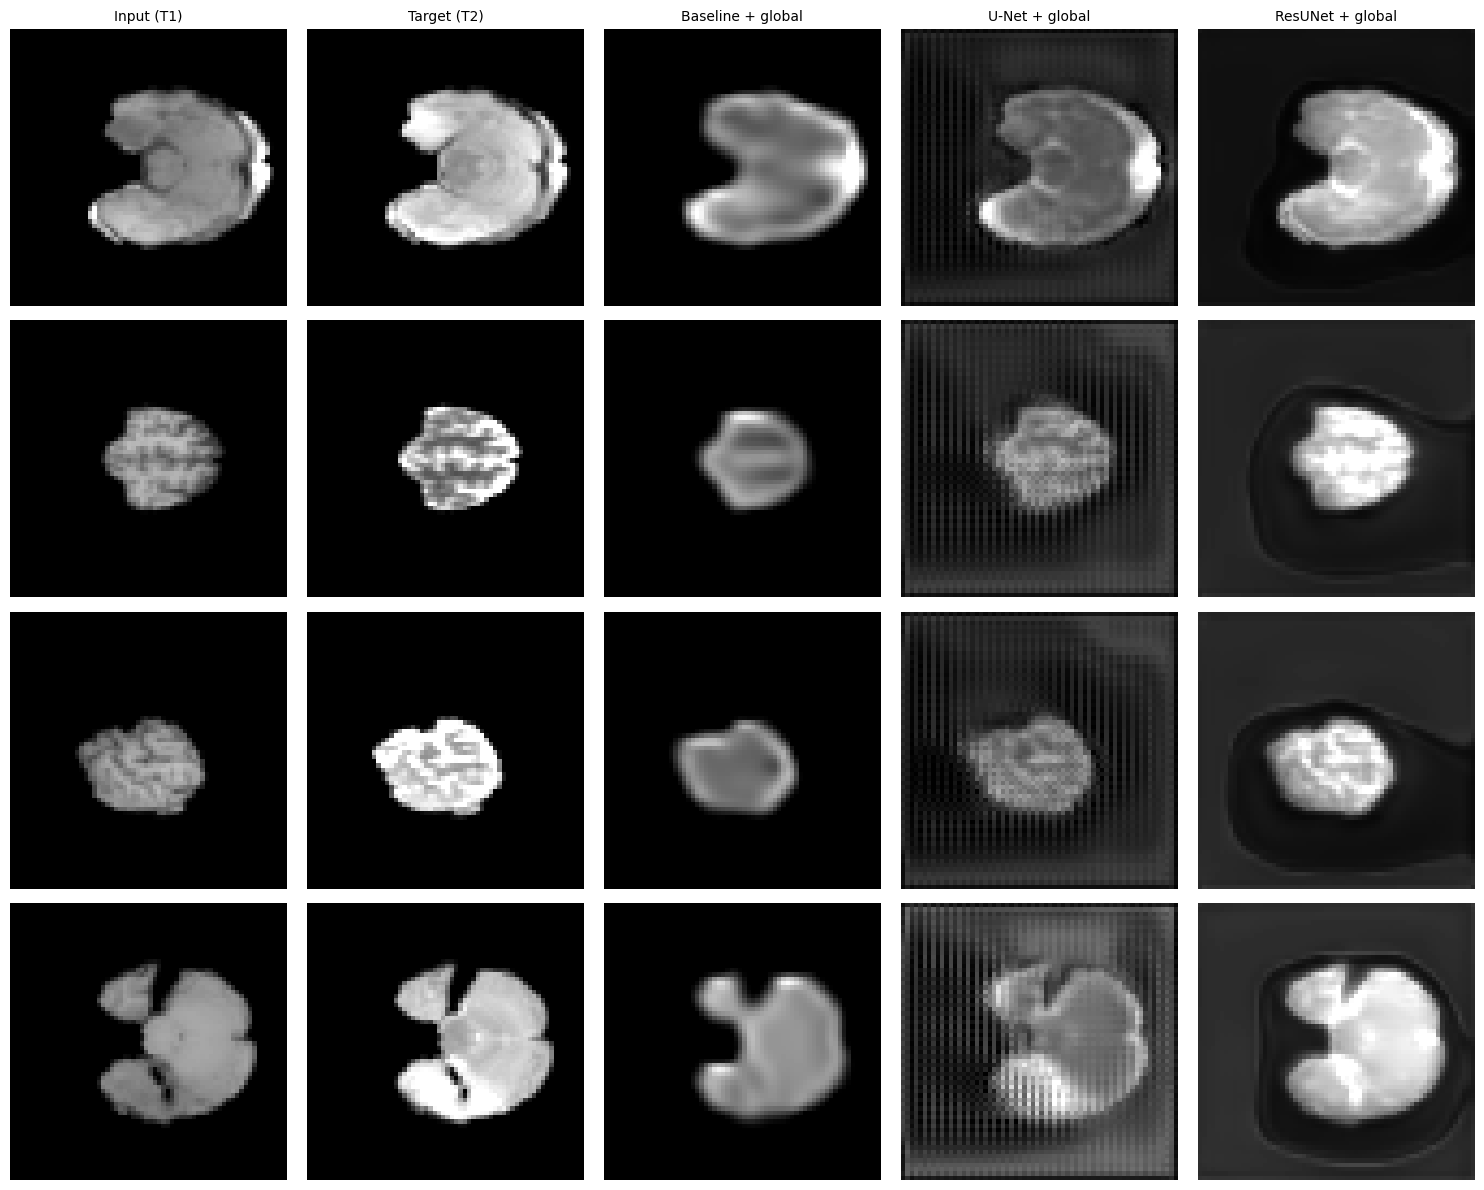

In [14]:
final_labels = ["Baseline + global", "U-Net + global", "ResUNet + global"]
final_col_labels = ["Input (T1)", "Target (T2)"] + final_labels

fig, axes = plt.subplots(len(selected_dataset_indices), len(final_col_labels), figsize=(3 * len(final_col_labels), 3 * len(selected_dataset_indices)))

for row_idx, sample_idx in enumerate(selected_dataset_indices):
    ref_input = run_outputs["ResUNet + global"]["input"][row_idx, 0].numpy()
    ref_target = run_outputs["ResUNet + global"]["target"][row_idx, 0].numpy()
    pred_arrays = [run_outputs[label]["pred"][row_idx, 0].numpy() for label in final_labels]
    vmin, vmax = robust_range(ref_input, ref_target, *pred_arrays, lower=1.0, upper=99.0)

    images = [ref_input, ref_target] + pred_arrays
    for col_idx, img in enumerate(images):
        axes[row_idx, col_idx].imshow(img, vmin=vmin, vmax=vmax)
        axes[row_idx, col_idx].axis("off")
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(final_col_labels[col_idx], fontsize=10)

    axes[row_idx, 0].set_ylabel(row_labels[row_idx], fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
save_path = ROOT / "reports" / "figures" / "qualitative_final_model_panel.png"
save_path.parent.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(len(selected_dataset_indices), len(final_col_labels), figsize=(3 * len(final_col_labels), 3 * len(selected_dataset_indices)))

for row_idx, sample_idx in enumerate(selected_dataset_indices):
    ref_input = run_outputs["ResUNet + global"]["input"][row_idx, 0].numpy()
    ref_target = run_outputs["ResUNet + global"]["target"][row_idx, 0].numpy()
    pred_arrays = [run_outputs[label]["pred"][row_idx, 0].numpy() for label in final_labels]
    vmin, vmax = robust_range(ref_input, ref_target, *pred_arrays, lower=1.0, upper=99.0)

    images = [ref_input, ref_target] + pred_arrays
    for col_idx, img in enumerate(images):
        axes[row_idx, col_idx].imshow(img, vmin=vmin, vmax=vmax)
        axes[row_idx, col_idx].axis("off")
        if row_idx == 0:
            axes[row_idx, col_idx].set_title(final_col_labels[col_idx], fontsize=10)

    axes[row_idx, 0].set_ylabel(row_labels[row_idx], fontsize=10)

plt.tight_layout()
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.close()

print("Saved:", save_path)

Saved: /home/dreadgator/mri-modality-translation/reports/figures/qualitative_final_model_panel.png


## Final-model interpretation

The final-model comparison highlights the actual progression of the repository:

- the encoder-decoder is useful as a low-capacity reference, but it is too blurry to serve as the final model
- the U-Net restores stronger structure, but its background behavior remains visibly less clean
- the final ResUNet gives the best overall balance between structural detail and reduced artifact severity

This is why the repository ends on `resunet_global_minmax`, even though the U-Net remains competitive on some pixel-wise metrics.

## Qualitative summary

The qualitative results support the same conclusion as the broader experiment set:

- the encoder-decoder is useful as a low-capacity stability baseline, but is too blurry to serve as the final model
- the standard U-Net improves structural detail, but leaves meaningful background artifacts
- percentile min-max is a useful failed ablation rather than the final preprocessing choice
- the final global-minmax ResUNet gives the best overall trade-off between structural fidelity and artifact control